In [1]:
import numpy as np
import torch


seed = 1712
np.random.seed(seed)
torch.manual_seed(seed)

In [2]:
hidden_channels = 64
num_gnn_layers = 3

In [3]:
num_ue = 6
num_ap = 30
num_antenna = 1
tau=20; power_f=0.2; D=1; f=1900; Hb=15; Hm=1.65; d0=0.01;d1=0.05;


noise_p = 10**((-203.975+10*np.log10(20*10**6)+9)/10);
rho_d = power_f/noise_p
rho_p = power_f/noise_p

In [4]:
import numpy as np
import scipy.io
from Utils.data_gen_ldpc import build_cen_loader_ldpc

def build_cen_loaders_for_scenario(
    num_ue,
    num_ap,
    batch_size,
    num_train,
    num_test,
    rho_d,
    seed=2024,
    data_dir='Data'
):
    """
    Tạo train_loader_cen, test_loader_cen cho 1 scenario (num_ue, num_ap)
    dùng đúng logic bạn đã viết.
    """
    file_name = f'dl_data_with_power_1000_{num_ue}_{num_ap}'
    mat_data = scipy.io.loadmat(f'{data_dir}/{file_name}.mat')

    beta_all  = mat_data['betas']
    gamma_all = mat_data['Gammas']
    power_all = mat_data['power'] / rho_d
    phi_all   = mat_data['Phii_cf'].transpose(0, 2, 1)
    opt_rates_all = mat_data['R_cf_opt_min'][0]  # nếu cần dùng để so sánh

    label_all = power_all

    # split train / test
    perm = np.random.RandomState(seed).permutation(beta_all.shape[0])
    train_idx = perm[:num_train]
    test_idx  = perm[num_train: num_train + num_test]

    # Centralized Data
    train_data_cen, train_loader_cen = build_cen_loader_ldpc(
        beta_all[train_idx],
        gamma_all[train_idx],
        label_all[train_idx],
        phi_all[train_idx],
        batch_size,
        isShuffle=True
    )
    test_data_cen, test_loader_cen = build_cen_loader_ldpc(
        beta_all[test_idx],
        gamma_all[test_idx],
        label_all[test_idx],
        phi_all[test_idx],
        batch_size
    )

    return {
        "train_loader": train_loader_cen,
        "test_loader":  test_loader_cen,
        "train_idx":    train_idx,
        "test_idx":     test_idx,
        "opt_rates":    opt_rates_all,  # full; nếu cần theo train/test thì tự slice
    }

c:\Users\wine\anaconda3\envs\new-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import torch
from torch.utils.data import DataLoader, random_split
num_ues = [6, 8, 10]      # ví dụ
num_aps = [30, 40, 50]       # ví dụ

num_rounds = 500
eval_round = num_rounds//10
batch_size = 32
num_train = 800
num_test = 200
num_eval = 500
lr = 5e-3
step_size = num_rounds//10
gamma = 0.8
client_fraction = 0.6
num_epochs = 1000
scenario_configs = []
for ue in num_ues:
    for ap in num_aps:
        scen_name = f"UE{ue}_AP{ap}"
        scen_info = build_cen_loaders_for_scenario(
            num_ue    = ue,
            num_ap    = ap,
            batch_size= batch_size,
            num_train = num_train,
            num_test  = num_test,
            rho_d     = rho_d,      # bạn đã định nghĩa ở ngoài
            seed      = seed,
            data_dir  = 'Data/dl_datasets'
        )
        scenario_configs.append({
            "name": scen_name,
            "num_ue": ue,
            "num_ap": ap,
            "train_loader": scen_info["train_loader"],
            "test_loader":  scen_info["test_loader"],
            "train_idx":    scen_info["train_idx"],
            "test_idx":     scen_info["test_idx"],
            "opt_rates":    scen_info["opt_rates"],
        })

c:\Users\wine\Giang\Code\Viet\new\densityevolution\GNN_FL_cf_mMIMO\Utils\data_gen_ldpc.py:152: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  data.y = torch.tensor([eta_single_all], dtype=torch.float32).to(device)


In [6]:
dim_dict = {
    'VN': 20,
    'CN': 1,
    'edge': 2,
}

metadata = [
    ('VN', 'to', 'CN'),
    ('CN', 'to', 'VN'),
]

In [7]:
from Models.LDPC_new import LDPCPowerGNN
from Utils.MTAdam import MTAdam, ldpc_loss_mtadam, ldpc_train_mtadam, ldpc_eval_mtadam,  beta3_schedule, update_alpha

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Khởi tạo model như bạn đang dùng
model = LDPCPowerGNN(
    vn_dim      = dim_dict['VN'],
    cn_dim      = dim_dict['CN'],
    edge_dim    = dim_dict['edge'],
    message_dim = 64,
    hidden      = 32,
    num_iter    = 3,
    gamma_idx   = 1,
    power_limit = rho_d,
).to(device)

optimizer = MTAdam(
    model.parameters(),
    lr=1e-3,
    betas=(0.9, 0.999, 0.9),
    eps=1e-8,
    weight_decay=0.0,
)

In [8]:
alpha_power = 1e-6      # weight cho power constraint
alpha_rate  = 1.0       # nếu bạn có dùng rate_constraint_loss
beta3_lo, beta3_hi = 0.5, 0.9
target_rate = 0.1       # ngưỡng min-rate
num_epochs_cen = 200

hist = {
    cfg["name"]: {
        "train_rate": [],
        "test_rate": [],
        "train_p_c": [],
        "test_p_c": [],
        "train_r_c": [],
        "test_r_c": [],
        "train_rate_viol": [],
        "test_rate_viol": [],
    }
    for cfg in scenario_configs
}


In [15]:
# khởi tạo hist theo từng scenario
hist = {
    cfg["name"]: {
        "train_rate": [],
        "test_rate": [],
        "train_p_c": [],
        "test_p_c": [],
        "train_rate_viol": []
    }
    for cfg in scenario_configs
}

for epoch in range(num_epochs_cen):
    epoch_ratio = epoch / max(1, (2 * num_epochs_cen // 3))

    # === update beta3 (MTAdam betas[2]) ===
    beta3_t = beta3_schedule(
        epoch,
        num_epochs_cen,
        beta3_start=beta3_lo,
        beta3_end=beta3_hi
    )
    for group in optimizer.param_groups:
        beta1, beta2, _ = group["betas"]
        group["betas"] = (beta1, beta2, beta3_t)

    # === train lần lượt trên từng scenario ===
    for cfg in scenario_configs:
        name         = cfg["name"]
        train_loader = cfg["train_loader"]
        test_loader  = cfg["test_loader"]

        # ---- train 1 epoch trên scenario này ----
        train_task_loss, train_p_c_loss = ldpc_train_mtadam(
            epochRatio   = epoch_ratio,
            dataLoader   = train_loader,
            model        = model,
            optimizer    = optimizer,
            tau          = tau,
            rho_p        = rho_p,
            rho_d        = rho_d,
            num_antenna  = num_antenna,
            alpha  = alpha_power,
            gamma_idx    = 1,
            power_limit  = 1.0,
        )

        # ---- eval trên train set ----
        train_rate, train_p_c_loss_eval = ldpc_eval_mtadam(
            dataLoader   = train_loader,
            model        = model,
            tau          = tau,
            rho_p        = rho_p,
            rho_d        = rho_d,
            num_antenna  = num_antenna,
            gamma_idx    = 1,
            power_limit  = 1.0
        )

        # ---- eval trên test set ----
        test_rate, test_p_c_loss_eval = ldpc_eval_mtadam(
            dataLoader   = test_loader,
            model        = model,
            tau          = tau,
            rho_p        = rho_p,
            rho_d        = rho_d,
            num_antenna  = num_antenna,
            gamma_idx    = 1,
            power_limit  = 1.0,
        )

        # ---- update alpha_power từ power-constraint loss của scenario này ----
        alpha_power = update_alpha(
            alpha_old   = alpha_power,
            c_loss_epoch= train_p_c_loss,
            c_high      = 1e-2,
            c_low       = 1e-4,
            up_factor   = 1.05,
            down_factor = 0.9,
            alpha_min   = 1e-7,
            alpha_max   = 1e-6,
        )

        # ---- lưu lịch sử cho từng scenario ----
        # hist[name]["train_task_loss"].append(train_task_loss)
        hist[name]["train_rate"].append(train_rate)
        hist[name]["test_rate"].append(test_rate)
        hist[name]["train_p_c"].append(train_p_c_loss_eval)
        hist[name]["test_p_c"].append(test_p_c_loss_eval)

        # ---- log ----
        print(
            f"[{name}] Epoch {epoch+1:03d}/{num_epochs_cen} | "
            f"beta3={beta3_t:.4f} | "
            f"alpha_power={alpha_power:.4e} | "
            f"Train Task Loss={train_task_loss:.4f} | "
            f"Train Power C Loss={train_p_c_loss_eval:.4e} | "
            f"Train Rate={train_rate:.4f} | "
            f"Test Rate={test_rate:.4f} | "
            f"Test Power C Loss={test_p_c_loss_eval:.4e} | "
        )


[UE6_AP30] Epoch 001/200 | beta3=0.5000 | alpha_power=8.1000e-07 | Train Task Loss=-0.6424 | Train Power C Loss=0.0000e+00 | Train Rate=0.6060 | Test Rate=0.6383 | Test Power C Loss=0.0000e+00 | 
[UE6_AP40] Epoch 001/200 | beta3=0.5000 | alpha_power=7.2900e-07 | Train Task Loss=-0.7912 | Train Power C Loss=0.0000e+00 | Train Rate=0.8544 | Test Rate=0.8727 | Test Power C Loss=0.0000e+00 | 
[UE6_AP50] Epoch 001/200 | beta3=0.5000 | alpha_power=6.5610e-07 | Train Task Loss=-0.9187 | Train Power C Loss=0.0000e+00 | Train Rate=0.9382 | Test Rate=0.9498 | Test Power C Loss=0.0000e+00 | 
[UE8_AP30] Epoch 001/200 | beta3=0.5000 | alpha_power=5.9049e-07 | Train Task Loss=-0.3567 | Train Power C Loss=0.0000e+00 | Train Rate=0.4542 | Test Rate=0.4415 | Test Power C Loss=0.0000e+00 | 
[UE8_AP40] Epoch 001/200 | beta3=0.5000 | alpha_power=5.3144e-07 | Train Task Loss=-0.6110 | Train Power C Loss=0.0000e+00 | Train Rate=0.6149 | Test Rate=0.5655 | Test Power C Loss=0.0000e+00 | 
[UE8_AP50] Epoch 001

# Results

In [16]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import scipy.io

from Utils.centralized_train import component_calculate, rate_from_component, rate_calculation


@torch.no_grad()
def collect_min_rates_model(
    loader,
    model,
    tau, rho_p, rho_d, num_antenna,
    edge_key=('CN', 'to', 'VN')
):
    """
    Min-rate per graph từ GNN (trên test_loader).
    """
    device = next(model.parameters()).device
    model.eval()

    all_min_rates = []

    for batch in loader:
        batch = batch.to(device)
        num_graph = batch.num_graphs

        x_dict, edge_dict, edge_index_dict = model(batch)

        num_APs = batch['CN'].x.shape[0] // num_graph
        num_UEs = batch['VN'].x.shape[0] // num_graph

        edge_feat      = edge_dict[edge_key]      # [E, F]
        edge_dim_total = edge_feat.size(-1)
        edge_feat_4d   = edge_feat.view(num_graph, num_APs, num_UEs, edge_dim_total)

        large_scale  = torch.expm1(edge_feat_4d[:, :, :, 0])          # [G,M,K]
        phi_matrix   = batch['VN'].x.view(num_graph, num_UEs, -1)     # [G,K,d]
        channel_var  = edge_feat_4d[:, :, :, 1]                       # [G,M,K]
        power_matrix = edge_feat_4d[:, :, :, -1]                      # [G,M,K]

        all_DS, all_PC, all_UI = component_calculate(
            power_matrix, channel_var, large_scale, phi_matrix, rho_d=rho_d
        )
        rate = rate_from_component(
            all_DS, all_PC, all_UI, num_antenna, rho_d=rho_d
        )   # [G, K]

        min_rate_per_graph, _ = torch.min(rate, dim=1)  # [G]
        all_min_rates.append(min_rate_per_graph.cpu().numpy())

    if len(all_min_rates) == 0:
        return np.array([])

    min_rates = np.concatenate(all_min_rates, axis=0)
    min_rates = np.clip(min_rates, 0.0, None)
    return min_rates


def collect_min_rates_opt_and_full(
    num_ue,
    num_ap,
    test_idx,
    rho_d,
    tau, rho_p, rho_d_data, num_antenna,   # rho_d_data nếu khác cũng có thể = rho_d
    data_dir='Data'
):
    """
    Min-rate optimal (từ R_cf_opt_min) và min-rate full power (=1) cho test set.
    test_idx: index các mẫu test trong file .mat (giống khi build loader).
    """
    file_name = f'dl_data_with_power_1000_{num_ue}_{num_ap}'
    mat_data = scipy.io.loadmat(f'{data_dir}/dl_datasets/{file_name}.mat')

    beta_all   = mat_data['betas']      # [N,M,K]
    gamma_all  = mat_data['Gammas']     # [N,M,K]
    power_all  = mat_data['power'] / rho_d
    phi_all    = mat_data['Phii_cf'].transpose(0, 2, 1)  # [N,K,tau]
    opt_all    = mat_data['R_cf_opt_min'][0]             # [N]

    idx = test_idx

    # Optimal min-rate per sample đã có sẵn
    min_opt = opt_all[idx]   # numpy 1D

    # Full-power baseline: p = 1 mọi link
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    beta   = torch.from_numpy(beta_all[idx]).float().to(device)   # [G,M,K]
    gamma  = torch.from_numpy(gamma_all[idx]).float().to(device)  # [G,M,K]
    phi    = torch.from_numpy(phi_all[idx]).float().to(device)    # [G,K,tau]

    full_power = torch.ones_like(beta, dtype=torch.float32, device=device)

    rate_full = rate_calculation(
        full_power,
        beta,
        gamma,
        phi,
        rho_d_data,
        num_antenna
    )   # [G,K]

    min_full, _ = torch.min(rate_full, dim=1)      # [G]
    min_full = min_full.cpu().numpy()

    min_opt  = np.clip(min_opt,  0.0, None)
    min_full = np.clip(min_full, 0.0, None)

    return min_opt, min_full


def plot_cdf(ax, data, label, linestyle='-'):
    data = np.asarray(data)
    if data.size == 0:
        return
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, label=label, linestyle=linestyle, linewidth=2)


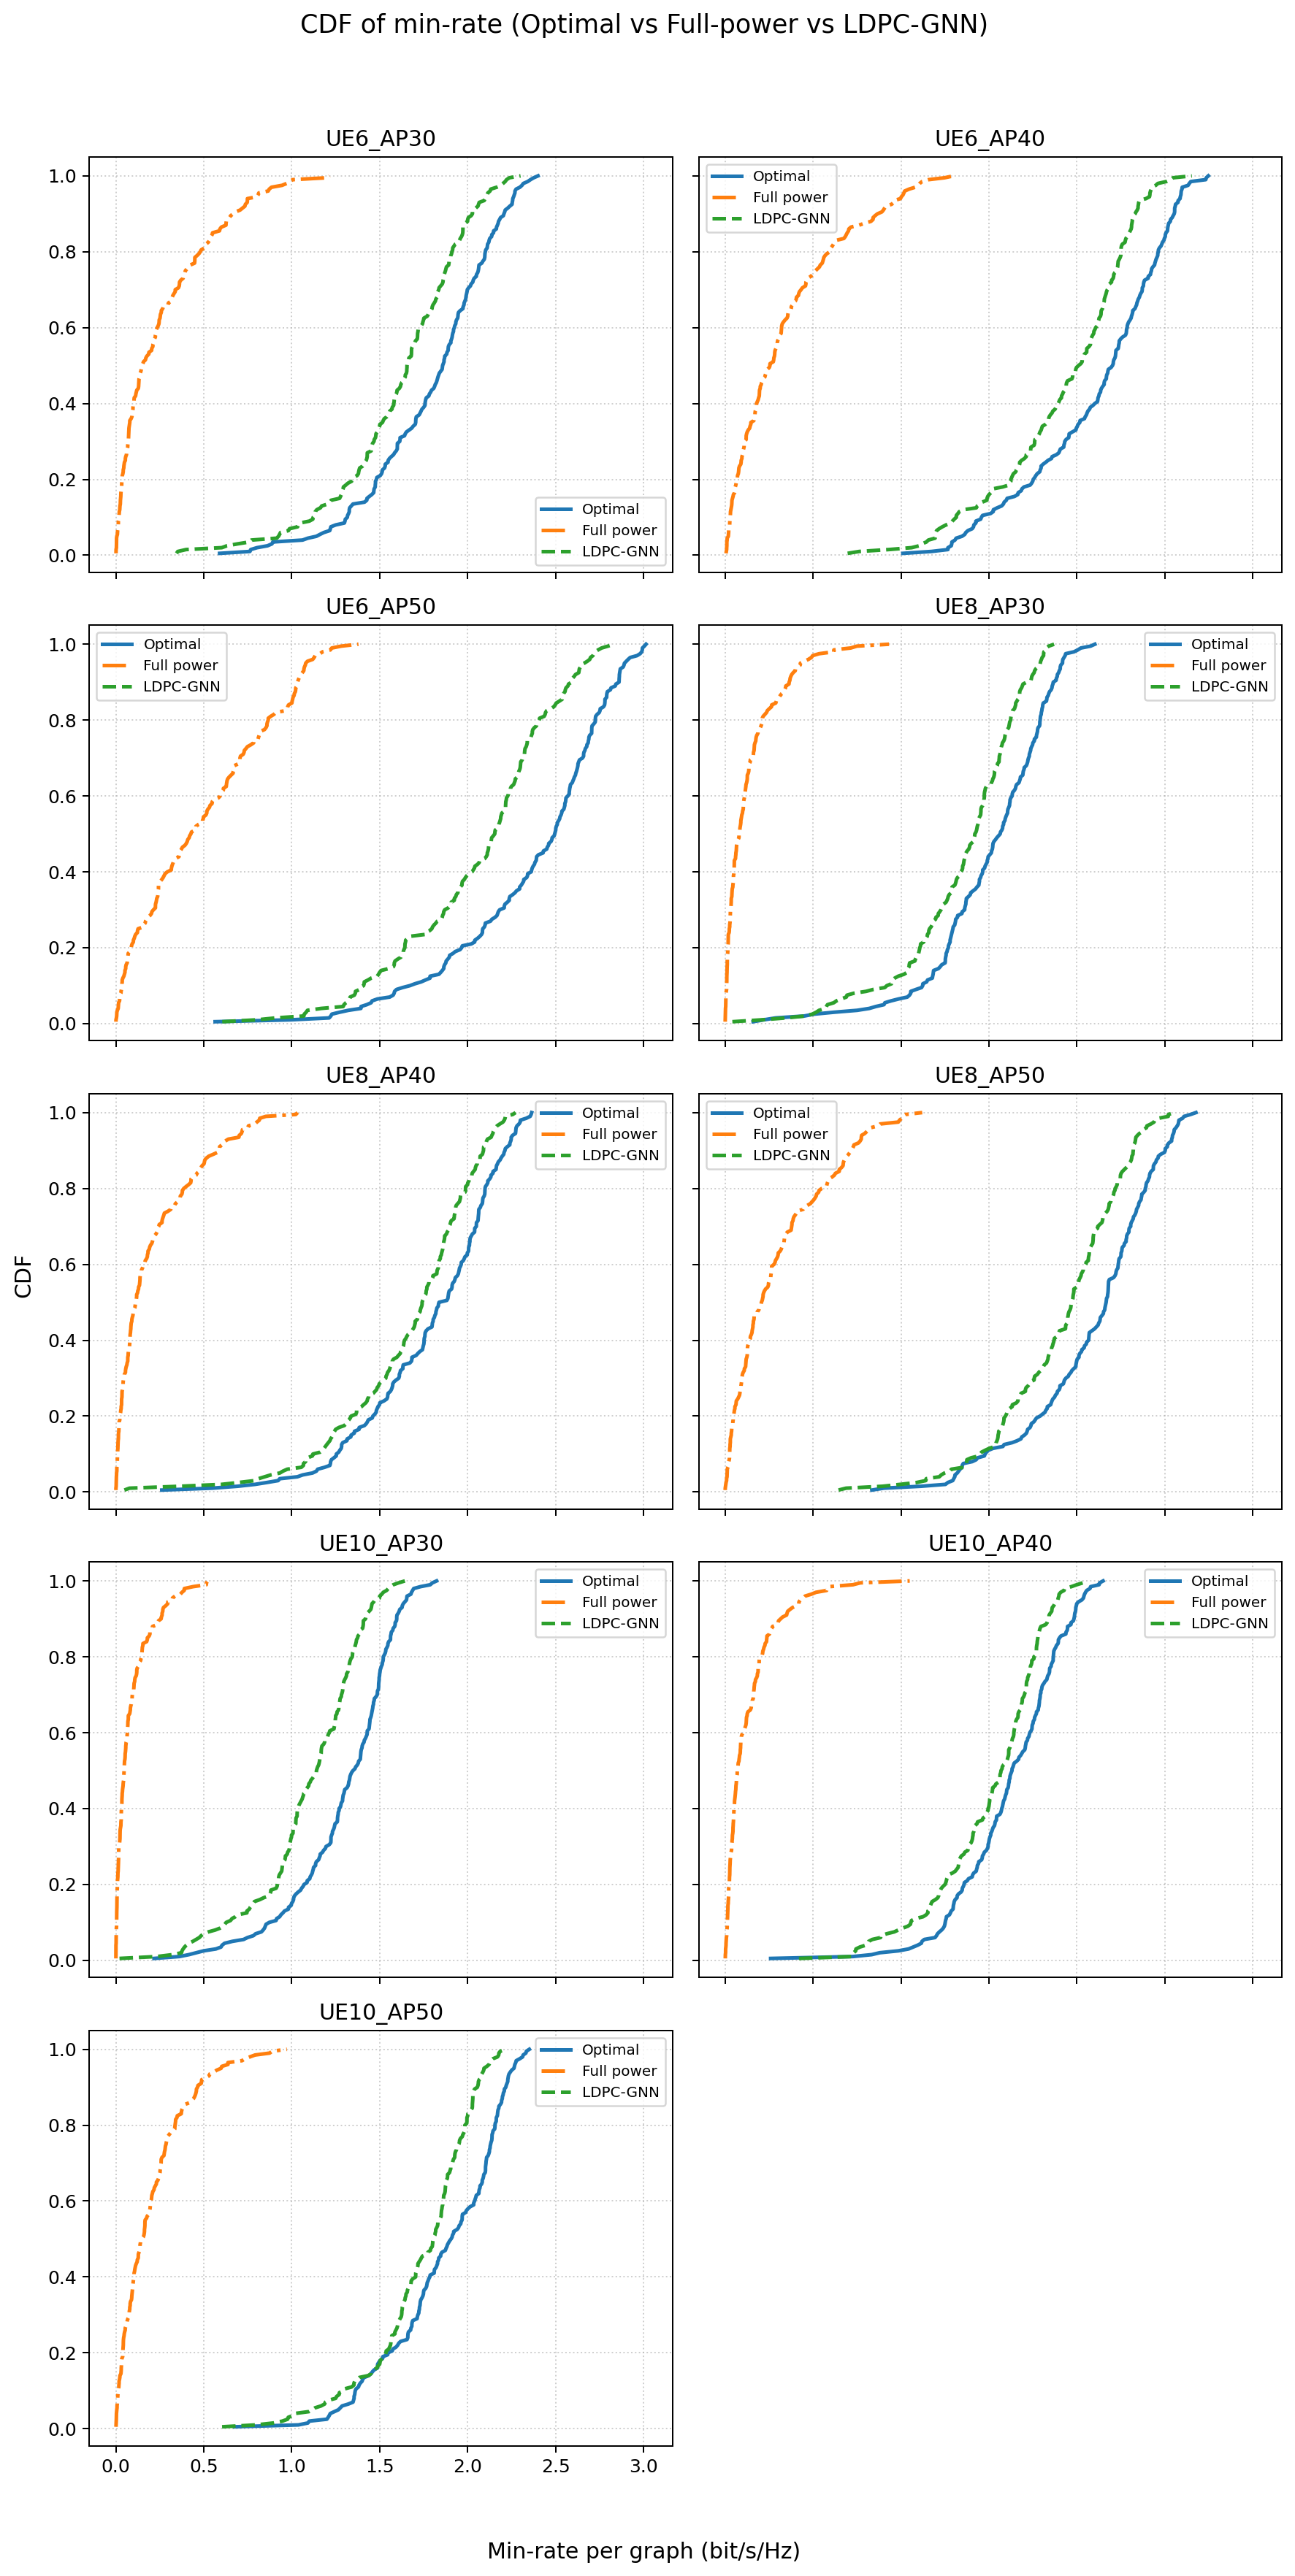

In [17]:
n_scen = len(scenario_configs)
n_cols = 2
n_rows = math.ceil(n_scen / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    dpi=180,
    sharex=True,
    sharey=True
)

# nếu chỉ có 1 hàng/1 cột thì flatten cho dễ xử lý
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

for i, cfg in enumerate(scenario_configs):
    ax = axes[i]
    name        = cfg["name"]
    num_ue      = cfg["num_ue"]
    num_ap      = cfg["num_ap"]
    test_loader = cfg["test_loader"]
    test_idx    = cfg["test_idx"]

    # 1) GNN min-rate
    min_gnn = collect_min_rates_model(
        loader      = test_loader,
        model       = model,
        tau         = tau,
        rho_p       = rho_p,
        rho_d       = rho_d,
        num_antenna = num_antenna,
    )

    # 2) Optimal & full-power baseline từ .mat
    min_opt, min_full = collect_min_rates_opt_and_full(
        num_ue      = num_ue,
        num_ap      = num_ap,
        test_idx    = test_idx,
        rho_d       = rho_d,
        tau         = tau,
        rho_p       = rho_p,
        rho_d_data  = rho_d,
        num_antenna = num_antenna,
        data_dir    = 'Data'
    )

    # Vẽ CDF 3 đường
    plot_cdf(ax, min_opt,  label='Optimal',       linestyle='-')
    plot_cdf(ax, min_full, label='Full power',    linestyle='-.')
    plot_cdf(ax, min_gnn,  label='LDPC-GNN',      linestyle='--')

    ax.set_title(name, fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=8)

# Ẩn subplot thừa nếu có
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.supxlabel('Min-rate per graph (bit/s/Hz)', fontsize=12)
fig.supylabel('CDF', fontsize=12)
fig.suptitle('CDF of min-rate (Optimal vs Full-power vs LDPC-GNN)', fontsize=14)
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()